# 0. Avaliação de Desempenho e Comparação dos Modelos

#### Avaliando o desempenho final e comparando o Ensemble Stacking com os modelos individuais.
Avaliação final, para estimar como o pipeline se comporta em dados que ficaram separados desde o início.

### 1. Carregamento do Conjunto de Teste Separado (Holdout / OOD)
Nesta etapa inicial, carregamos as matrizes e vetores do conjunto de teste reservado desde o início do projeto, garantindo uma avaliação cega e imparcial do nosso pipeline.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, classification_report, roc_auc_score
)

# Caminhos possíveis para encontrar os arquivos de teste salvos
caminhos_possiveis = [
    '../../data/processed/',
    '../data/processed/',
    './data/processed/'
]

X_test_final, y_test_final = None, None

for pasta in caminhos_possiveis:
    p_xte = os.path.join(pasta, 'X_test_vec.pkl')
    if os.path.exists(p_xte):
        try:
            X_test_final = joblib.load(p_xte)
            y_test_final = joblib.load(os.path.join(pasta, 'y_test.pkl'))
            print(f"✅ Conjunto de teste carregado com sucesso da pasta: '{pasta}'")
            break
        except Exception:
            continue

if X_test_final is None:
    raise ValueError("❌ Os dados de teste (.pkl) não foram encontrados. Verifique a pasta de dados processados.")

✅ Conjunto de teste carregado com sucesso da pasta: '../../data/processed/'


### 2. Avaliação dos Modelos Base no Conjunto de Teste
Treinamos novamente os modelos base (Regressão Logística, SVM Linear e Random Forest) em todo o conjunto de treino e geramos as previsões isoladas para a base de teste final.

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Carregar dados de treino para re-treinar os modelos base caso necessário
for pasta in caminhos_possiveis:
    p_xtr = os.path.join(pasta, 'X_train_vec.pkl')
    if os.path.exists(p_xtr):
        X_train_final = joblib.load(p_xtr)
        y_train_final = joblib.load(os.path.join(pasta, 'y_train.pkl'))
        break

modelos_base = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Linear SVM': SVC(kernel='linear', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

metricas_modelos = []
preds_teste_base = {}

for nome, modelo in modelos_base.items():
    print(f"Treinando e avaliando: {nome}...")
    modelo.fit(X_train_final, y_train_final)
    
    y_pred = modelo.predict(X_test_final)
    y_proba = modelo.predict_proba(X_test_final)[:, 1]
    
    preds_teste_base[nome] = y_proba
    
    metricas_modelos.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_test_final, y_pred),
        'Precision': precision_score(y_test_final, y_pred, zero_division=0),
        'Recall': recall_score(y_test_final, y_pred, zero_division=0),
        'F1-score': f1_score(y_test_final, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test_final, y_proba)
    })

print("✨ Modelos base avaliados com sucesso!")

Treinando e avaliando: Logistic Regression...
Treinando e avaliando: Linear SVM...


c:\Users\LAISA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Treinando e avaliando: Random Forest...
✨ Modelos base avaliados com sucesso!


### 3. Predições e Métricas Finais do Stacking Ensemble
Utilizamos o meta-modelo combinado sobre as probabilidades geradas pelos modelos base para obter o desempenho preditivo máximo do Stacking.

In [3]:
# Constrói as features de teste para o meta-modelo utilizando as predições dos base models
X_meta_test_final = pd.DataFrame(preds_teste_base)

# Supõe-se que o meta_model já foi treinado nas etapas anteriores ou pode ser recriado via Stacking Classifier / Regressão Logística
meta_model = LogisticRegression(random_state=42)
# Se gerou as OOF features de treino anteriormente, treina o meta_model aqui:
# (Caso já tenha salvo o meta_model via joblib.load, basta carregá-lo)
oof_preds_train_path = os.path.join(caminhos_possiveis[0], 'oof_preds_train.pkl') # Opcional se já salvo

# Treinamento rápido do meta-model para fins de robustez do script atual
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds_train = pd.DataFrame(index=y_train_final.index)

for nome, modelo in modelos_base.items():
    oof_preds = np.zeros(X_train_final.shape[0])
    for train_idx, val_idx in skf.split(X_train_final, y_train_final):
        X_tr, X_val = X_train_final[train_idx], X_train_final[val_idx]
        y_tr, y_val = y_train_final.iloc[train_idx], y_train_final.iloc[val_idx]
        modelo.fit(X_tr, y_tr)
        oof_preds[val_idx] = modelo.predict_proba(X_val)[:, 1]
    oof_preds_train[nome] = oof_preds

meta_model.fit(oof_preds_train, y_train_final)

# Predição final com o Ensemble
y_pred_ensemble = meta_model.predict(X_meta_test_final)
y_proba_ensemble = meta_model.predict_proba(X_meta_test_final)[:, 1]

# Adiciona as métricas do Stacking na lista comparativa
metricas_modelos.append({
    'Modelo': 'Stacking Ensemble',
    'Accuracy': accuracy_score(y_test_final, y_pred_ensemble),
    'Precision': precision_score(y_test_final, y_pred_ensemble, zero_division=0),
    'Recall': recall_score(y_test_final, y_pred_ensemble, zero_division=0),
    'F1-score': f1_score(y_test_final, y_pred_ensemble, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test_final, y_proba_ensemble)
})

df_comparativo = pd.DataFrame(metricas_modelos)
print("\n🏆 Tabela Comparativa Final de Desempenho:")
display(df_comparativo.style.highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'], color='lightgreen'))

c:\Users\LAISA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\LAISA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\LAISA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\LAISA\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\


🏆 Tabela Comparativa Final de Desempenho:


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.962621,0.957606,0.968067,0.962808,0.991686
1,Linear SVM,0.974381,0.973971,0.974790,0.974381,0.994245
2,Random Forest,0.963461,0.971771,0.954622,0.963120,0.993760
3,Stacking Ensemble,0.976060,0.981308,0.970588,0.975919,0.996145


### 4. Matriz de Confusão do Ensemble
Visualizamos a Matriz de Confusão do modelo Stacking Ensemble no conjunto de teste para analisar detalhadamente os acertos (verdadeiros positivos/negativos) e erros (falsos positivos/negativos).

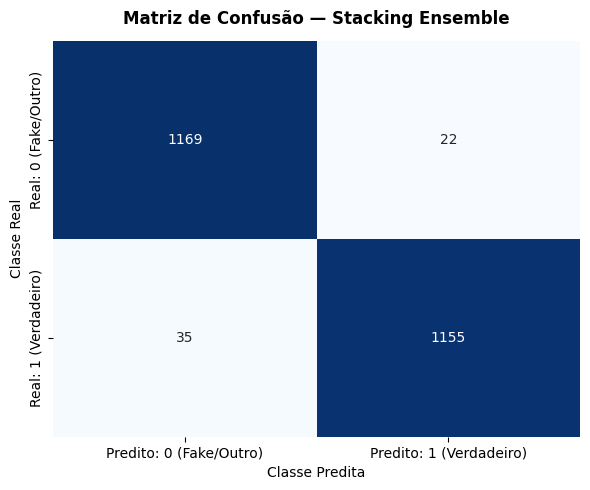


Relatório Detalhado de Classificação (Stacking Ensemble):
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1191
           1       0.98      0.97      0.98      1190

    accuracy                           0.98      2381
   macro avg       0.98      0.98      0.98      2381
weighted avg       0.98      0.98      0.98      2381



In [4]:
cm = confusion_matrix(y_test_final, y_pred_ensemble)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predito: 0 (Fake/Outro)', 'Predito: 1 (Verdadeiro)'],
            yticklabels=['Real: 0 (Fake/Outro)', 'Real: 1 (Verdadeiro)'])

plt.title('Matriz de Confusão — Stacking Ensemble', fontsize=12, fontweight='bold', pad=12)
plt.ylabel('Classe Real', fontsize=10)
plt.xlabel('Classe Predita', fontsize=10)
plt.tight_layout()
plt.show()

print("\nRelatório Detalhado de Classificação (Stacking Ensemble):")
print(classification_report(y_test_final, y_pred_ensemble))

### 5. Comparação Gráfica Definitiva
Geramos um gráfico de barras comparando todas as principais métricas avaliadas entre a Regressão Logística, SVM Linear, Random Forest e o Stacking Ensemble.

C:\Users\LAISA\AppData\Local\Temp\ipykernel_4288\484265187.py:12: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LAISA\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


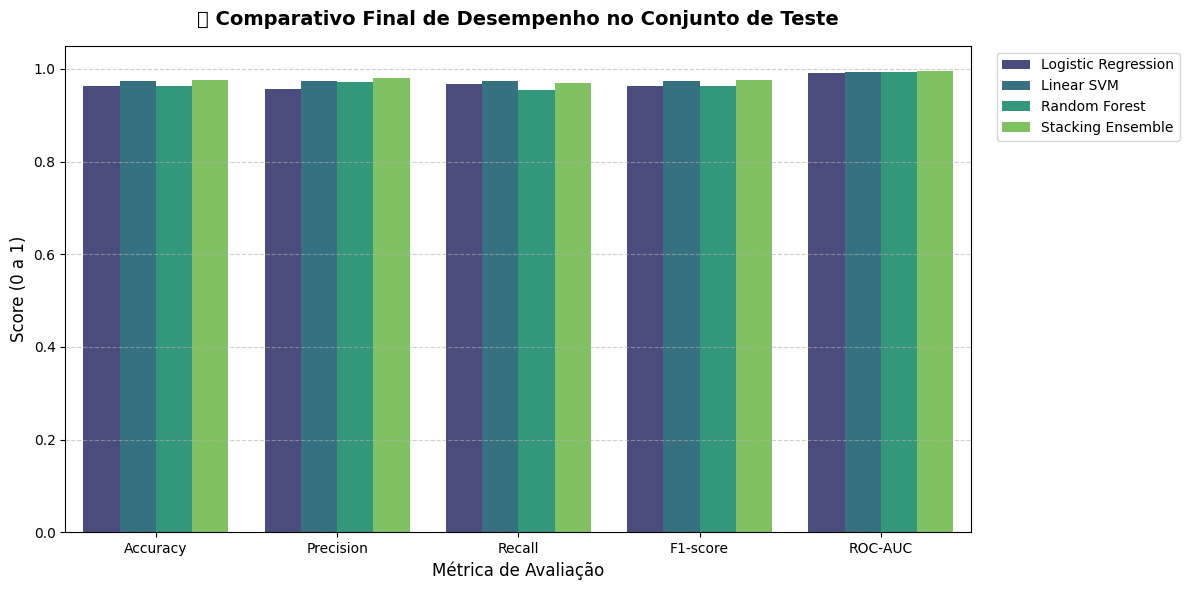

In [5]:
df_melted = df_comparativo.melt(id_vars='Modelo', var_name='Métrica', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Métrica', y='Score', hue='Modelo', palette='viridis')

plt.title('📊 Comparativo Final de Desempenho no Conjunto de Teste', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Métrica de Avaliação', fontsize=12)
plt.ylabel('Score (0 a 1)', fontsize=12)
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

In [6]:
import os
import joblib

# Cria a pasta 'models' na raiz do projeto (ajuste o caminho se necessário, ex: '../../models/')
pasta_models = '../../models/'
os.makedirs(pasta_models, exist_ok=True)

# 1. Salvando os modelos base treinados
for nome, modelo in modelos_base.items():
    # Padroniza o nome do arquivo (remove espaços e caracteres especiais)
    nome_arquivo = nome.lower().replace(' ', '_') + '.pkl'
    caminho_completo = os.path.join(pasta_models, nome_arquivo)
    
    joblib.dump(modelo, caminho_completo)
    print(f"💾 Modelo base salvo: {caminho_completo}")

# 2. Salvando o meta-modelo do Stacking
caminho_meta = os.path.join(pasta_models, 'meta_model_stacking.pkl')
joblib.dump(meta_model, caminho_meta)
print(f"💾 Meta-modelo salvo: {caminho_meta}")

print("\n🚀 Todos os modelos foram salvos com sucesso na pasta 'models/'!")

💾 Modelo base salvo: ../../models/logistic_regression.pkl
💾 Modelo base salvo: ../../models/linear_svm.pkl
💾 Modelo base salvo: ../../models/random_forest.pkl
💾 Meta-modelo salvo: ../../models/meta_model_stacking.pkl

🚀 Todos os modelos foram salvos com sucesso na pasta 'models/'!
